In [172]:
# 와인 예제

# 1. 필요한 라이브러리 임포트
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# 데이터 생성
wine = load_wine()

print("와인 종류:", wine.target)
print("이름들:", wine.feature_names)
print("총 개수:", len(wine.feature_names))


와인 종류: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
이름들: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
총 개수: 13


In [173]:
# 성능이 좋지 않은 이유가, 원래 독립 변수가 13개인데 그중 2개만 가져와서 학습했기 때문에
X = wine.data[:, [0, 2]]  # alcohol과 ash만 선택
y = wine.target  # 와인 종류 (0, 1, 2)

print("\n선택된 데이터 형태:", X.shape)
print("타겟 형태:", y.shape)


선택된 데이터 형태: (178, 2)
타겟 형태: (178,)


In [174]:
# 5. 학습용과 테스트용 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

print(f"\n학습 데이터: {X_train.shape}")
print(f"테스트 데이터: {X_test.shape}")

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n=== 모델 성능 ===")
print(f"정확도(Accuracy): {accuracy:.4f}")
print(f"\n분류 보고서:")
print(classification_report(y_test, y_pred, target_names=wine.target_names))


학습 데이터: (142, 2)
테스트 데이터: (36, 2)

=== 모델 성능 ===
정확도(Accuracy): 0.6667

분류 보고서:
              precision    recall  f1-score   support

     class_0       0.50      0.62      0.56         8
     class_1       0.89      0.84      0.86        19
     class_2       0.38      0.33      0.35         9

    accuracy                           0.67        36
   macro avg       0.59      0.60      0.59        36
weighted avg       0.67      0.67      0.67        36



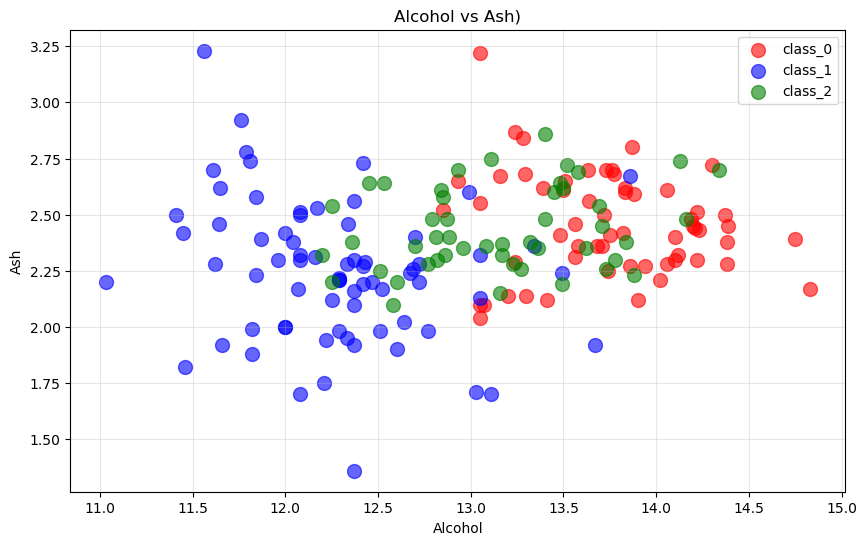

In [175]:
plt.figure(figsize=(10, 6))

colors = ['red', 'blue', 'green']
target_names = wine.target_names

for i, color in enumerate(colors):
    indices = y == i
    plt.scatter(X[indices, 0], X[indices, 1], 
                c=color, label=target_names[i], s=100, alpha=0.6)

plt.xlabel('Alcohol')
plt.ylabel('Ash')
plt.title('Alcohol vs Ash)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [176]:
print("\n=== 새로운 데이터 예측 ===")
new_wine = np.array([[12.5, 2.0]])  # alcohol=12.5, ash=2.0
prediction = model.predict(new_wine)
print(f"입력: Alcohol={new_wine[0, 0]}, Ash={new_wine[0, 1]}")
print(f"예측된 와인 종류: {wine.target_names[prediction[0]]}")


=== 새로운 데이터 예측 ===
입력: Alcohol=12.5, Ash=2.0
예측된 와인 종류: class_1
